# Modeling Human Activity States Using Hidden Markov Models


## 1. Background and Motivation

Human Activity Recognition (HAR) is a growing field that uses sensor data from smartphones and wearable devices to identify physical activities like walking, standing, jumping, and resting. Accurate activity classification has direct applications in personal fitness tracking and rehabilitation monitoring, where patients recovering from injuries need their exercises logged automatically to track compliance.

In this project, I collected accelerometer and gyroscope data from my smartphone and built a **Hidden Markov Model (HMM)** from scratch using NumPy. The HMM treats the true activity as a hidden state and the sensor-derived features as observable emissions. I implemented the **Baum-Welch algorithm** for training and the **Viterbi algorithm** for decoding the most likely activity sequence.

---

## 2. Data Collection

**App Used:** Sensor Logger (Android)  
**Sampling Rate:** 50 Hz (sample interval = 20 ms)  
**Device:** Android smartphone

I recorded four activities, each in separate sessions of about 6 to 7 seconds:

| Activity | Description | Files | Duration per file |
|----------|-------------|-------|-------------------|
| Standing | Phone held steady at waist level | 20 | ~6-7 seconds |
| Walking | Consistent walking pace, phone at waist | 20 | ~6-7 seconds |
| Jumping | Continuous vertical jumps | 20 | ~6-7 seconds |
| Still | Phone placed flat on a table, no movement | 20 | ~6-7 seconds |

**Total:** 80 CSV files, each containing accelerometer (x, y, z) and gyroscope (x, y, z) readings with timestamps.

**Sampling Rate Justification:** I chose 50 Hz because human motion typically occurs at frequencies below 20 Hz. By the Nyquist theorem, a 50 Hz rate captures all relevant motion frequencies without aliasing while keeping file sizes small.

In [1]:
import os

import numpy as np

import pandas as pd

import matplotlib

matplotlib.use('Agg')

import matplotlib.pyplot as plt

import seaborn as sns

from scipy.fft import fft, fftfreq

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import confusion_matrix

import warnings

warnings.filterwarnings('ignore')



plt.style.use('seaborn-v0_8-whitegrid')

sns.set_palette('Set2')



DATA_DIR = './data'

ACTIVITIES = ['standing', 'walking', 'jumping', 'still']

SAMPLING_RATE = 50



def load_session(session_path):

    """Load and merge accelerometer and gyroscope data from a session folder."""

    acc_path = os.path.join(session_path, 'Accelerometer.csv')

    gyro_path = os.path.join(session_path, 'Gyroscope.csv')

    if not (os.path.exists(acc_path) and os.path.exists(gyro_path)):

        return None

    acc = pd.read_csv(acc_path).rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})

    gyro = pd.read_csv(gyro_path).rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})

    acc = acc.sort_values('seconds_elapsed').reset_index(drop=True)

    gyro = gyro.sort_values('seconds_elapsed').reset_index(drop=True)

    merged = pd.merge_asof(

        acc[['seconds_elapsed', 'acc_x', 'acc_y', 'acc_z']],

        gyro[['seconds_elapsed', 'gyro_x', 'gyro_y', 'gyro_z']],

        on='seconds_elapsed', direction='nearest')

    return merged



all_data = {}

for activity in ACTIVITIES:

    activity_dir = os.path.join(DATA_DIR, activity)

    sessions = sorted([d for d in os.listdir(activity_dir)

                       if os.path.isdir(os.path.join(activity_dir, d))])

    all_data[activity] = []

    for session in sessions:

        df = load_session(os.path.join(activity_dir, session))

        if df is not None:

            df['activity'] = activity

            df['session'] = session

            all_data[activity].append(df)



print('=' * 65)

print('DATA COLLECTION SUMMARY')

print('=' * 65)

print(f'{"Activity":<12} {"Files":>6} {"Total Duration (s)":>20} {"Avg Samples/File":>18}')

print('-' * 65)

total_files = 0

for act in ACTIVITIES:

    n = len(all_data[act])

    total_files += n

    dur = sum(df['seconds_elapsed'].max() for df in all_data[act])

    avg_samples = np.mean([len(df) for df in all_data[act]])

    print(f'{act:<12} {n:>6} {dur:>20.1f} {avg_samples:>18.0f}')

print('-' * 65)

print(f'{"TOTAL":<12} {total_files:>6}')

DATA COLLECTION SUMMARY
Activity      Files   Total Duration (s)   Avg Samples/File
-----------------------------------------------------------------
standing         20                136.6                335
walking          20                137.2                338
jumping          20                140.0                344
still            20                138.7                342
-----------------------------------------------------------------
TOTAL            80


### 2.1 Raw Data Visualization

Below are sample accelerometer and gyroscope signals for each activity. These plots show the distinct motion patterns that the HMM needs to learn. Notice how jumping shows large spikes, walking shows a periodic pattern, while standing and still are relatively flat.

Figure saved: raw_sensor_data.png


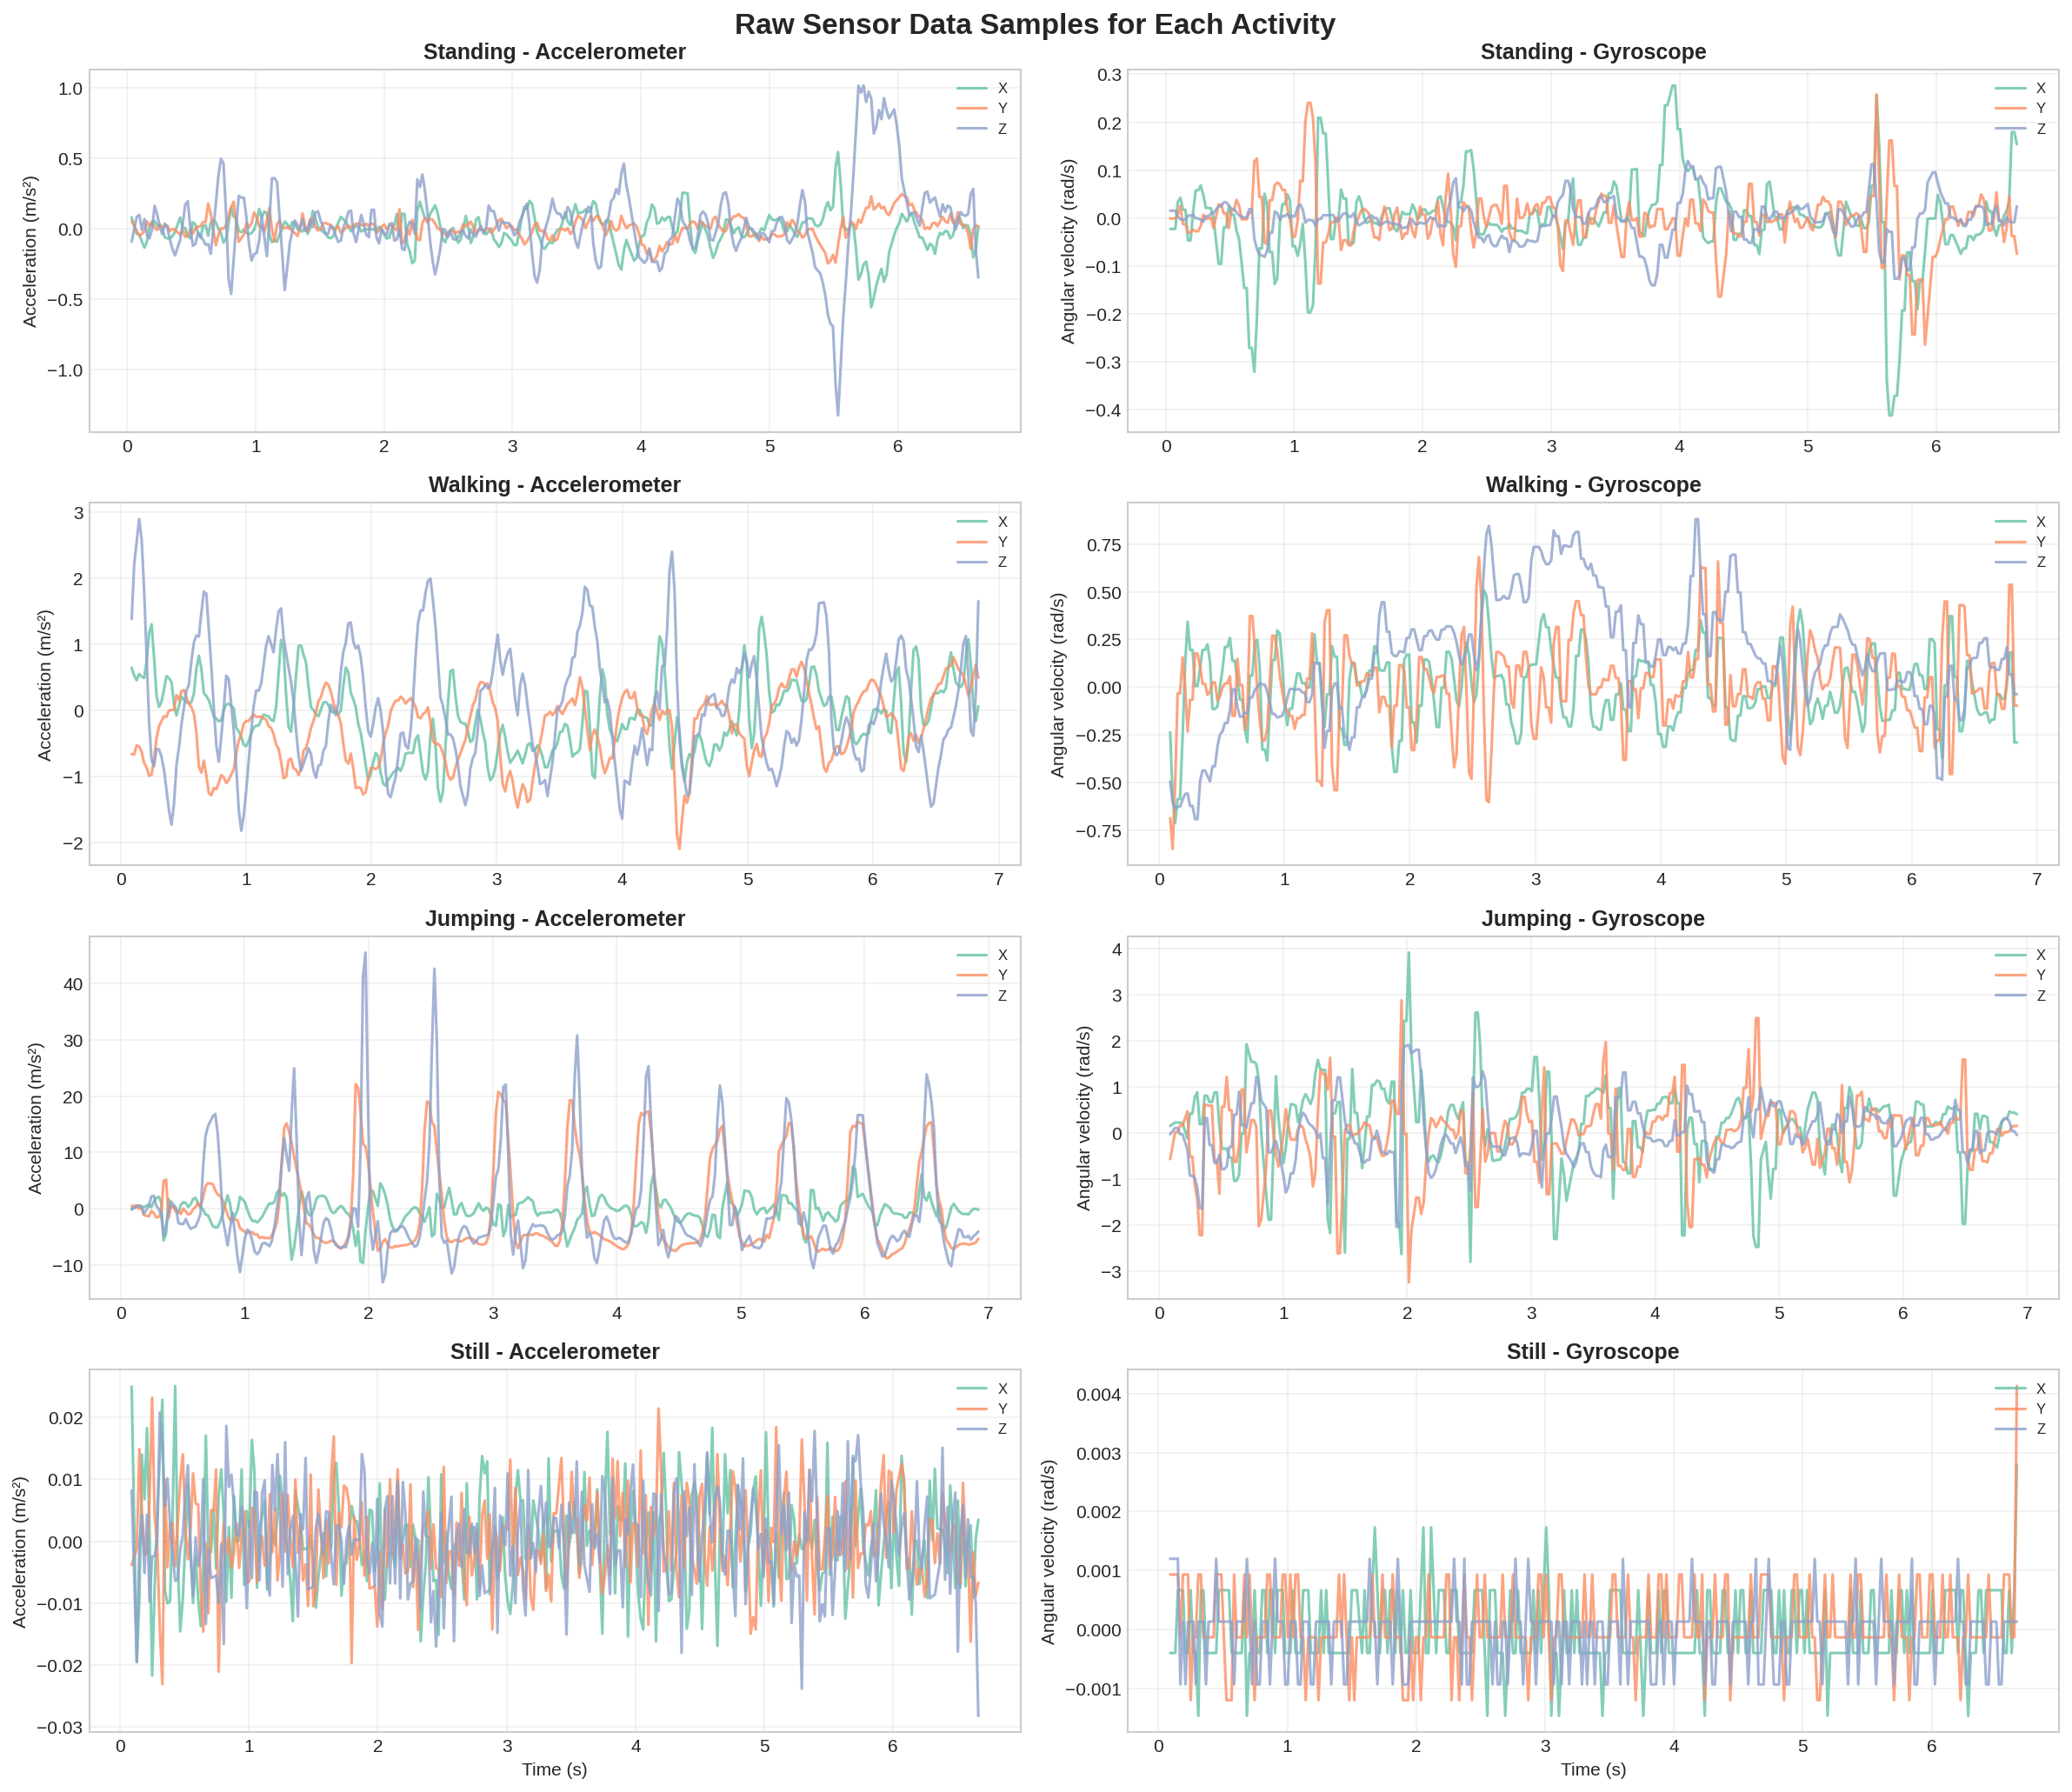

In [2]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))

fig.suptitle('Raw Sensor Data Samples for Each Activity', fontsize=16, fontweight='bold')

for i, activity in enumerate(ACTIVITIES):

    sample = all_data[activity][0]

    t = sample['seconds_elapsed']

    ax = axes[i, 0]

    ax.plot(t, sample['acc_x'], label='X', alpha=0.8)

    ax.plot(t, sample['acc_y'], label='Y', alpha=0.8)

    ax.plot(t, sample['acc_z'], label='Z', alpha=0.8)

    ax.set_title(f'{activity.capitalize()} - Accelerometer', fontweight='bold')

    ax.set_ylabel('Acceleration (m/s\u00b2)')

    ax.legend(loc='upper right', fontsize=8)

    ax.grid(True, alpha=0.3)

    if i == 3: ax.set_xlabel('Time (s)')

    ax = axes[i, 1]

    ax.plot(t, sample['gyro_x'], label='X', alpha=0.8)

    ax.plot(t, sample['gyro_y'], label='Y', alpha=0.8)

    ax.plot(t, sample['gyro_z'], label='Z', alpha=0.8)

    ax.set_title(f'{activity.capitalize()} - Gyroscope', fontweight='bold')

    ax.set_ylabel('Angular velocity (rad/s)')

    ax.legend(loc='upper right', fontsize=8)

    ax.grid(True, alpha=0.3)

    if i == 3: ax.set_xlabel('Time (s)')

plt.tight_layout()

plt.savefig('raw_sensor_data.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: raw_sensor_data.png')

---

## 3. Feature Extraction

### 3.1 Windowing Strategy

I divided each recording into **1-second non-overlapping windows**. At 50 Hz, each window has about 50 data points.

**Why 1-second windows?** At 50 Hz, one second gives 50 samples. This is enough to:
- Compute stable statistics (mean, variance, RMS)
- Capture at least one full cycle of walking (~2 Hz) or jumping (~2-3 Hz) through the FFT
- Keep the time resolution fine enough to detect transitions between activities

The window size is directly tied to the sampling rate: with 50 Hz, a 1-second window captures 50 samples, giving a frequency resolution of 1 Hz in the FFT (sufficient to distinguish the dominant frequencies of each activity).

### 3.2 Feature Descriptions and Justifications

I extracted **6 features per axis** across 6 axes (acc_x, acc_y, acc_z, gyro_x, gyro_y, gyro_z), giving 36 axis-level features, plus 2 cross-axis features (SMA and axis correlation), for a total of **38 features per window**.

#### Time-Domain Features

| Feature | Why It Helps |
|---------|--------------|
| **Mean** | Captures the average sensor reading. Gravity causes standing to have a specific mean on the z-axis. |
| **Variance** | Measures how spread out the signal is. Jumping has high variance, still has near-zero variance. |
| **Standard Deviation** | Same idea as variance but in original units, easier to interpret. |
| **Root Mean Square (RMS)** | Captures signal energy regardless of sign. Walking has moderate RMS, jumping has high RMS. |
| **Signal Magnitude Area (SMA)** | A single number for total body acceleration. Strongly separates dynamic from static activities. |

#### Frequency-Domain Features (derived from FFT)

| Feature | Why It Helps |
|---------|--------------|
| **Dominant Frequency** | Walking peaks at ~2 Hz, jumping at ~2-3 Hz, still at ~0 Hz. Directly identifies periodic motion. |
| **Spectral Energy** | Total energy in the frequency domain. High for dynamic activities, low for static ones. |

#### Cross-Axis Feature

| Feature | Why It Helps |
|---------|--------------|
| **Acc XY Correlation** | Walking creates coordinated x-y motion (correlated), while standing produces random uncorrelated noise. |

In [3]:
def extract_features(window_df):

    """Extract time-domain and frequency-domain features from one data window."""

    features = {}

    axes = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

    for axis in axes:

        data = window_df[axis].values

        n = len(data)

        if n == 0:

            continue

        # Time-domain features

        features[f'{axis}_mean'] = np.mean(data)

        features[f'{axis}_var'] = np.var(data)

        features[f'{axis}_std'] = np.std(data)

        features[f'{axis}_rms'] = np.sqrt(np.mean(data ** 2))

        # Frequency-domain features (FFT)

        fft_vals = np.abs(fft(data))

        freqs = fftfreq(n, d=1.0 / SAMPLING_RATE)

        pos_mask = freqs > 0

        if np.any(pos_mask):

            pos_fft = fft_vals[pos_mask]

            pos_freqs = freqs[pos_mask]

            features[f'{axis}_dominant_freq'] = pos_freqs[np.argmax(pos_fft)]

            features[f'{axis}_spectral_energy'] = np.sum(pos_fft ** 2) / len(pos_fft)

        else:

            features[f'{axis}_dominant_freq'] = 0.0

            features[f'{axis}_spectral_energy'] = 0.0

    # Signal Magnitude Area (SMA) for accelerometer

    acc_data = window_df[['acc_x', 'acc_y', 'acc_z']].values

    features['acc_sma'] = np.mean(np.sum(np.abs(acc_data), axis=1))

    # Cross-axis correlation (acc_x vs acc_y)

    if len(window_df) > 2:

        corr = np.corrcoef(window_df['acc_x'].values, window_df['acc_y'].values)[0, 1]

        features['acc_xy_corr'] = corr if not np.isnan(corr) else 0.0

    else:

        features['acc_xy_corr'] = 0.0

    return features



WINDOW_SIZE = 1.0

MIN_SAMPLES = 30

all_features = []

for activity in ACTIVITIES:

    for session_df in all_data[activity]:

        session_name = session_df['session'].iloc[0]

        max_time = session_df['seconds_elapsed'].max()

        window_start = 0

        window_id = 0

        while window_start + WINDOW_SIZE <= max_time:

            mask = ((session_df['seconds_elapsed'] >= window_start) &

                    (session_df['seconds_elapsed'] < window_start + WINDOW_SIZE))

            window_data = session_df[mask]

            if len(window_data) >= MIN_SAMPLES:

                feats = extract_features(window_data)

                feats['activity'] = activity

                feats['session'] = session_name

                feats['window_id'] = window_id

                all_features.append(feats)

            window_start += WINDOW_SIZE

            window_id += 1



features_df = pd.DataFrame(all_features)

feature_cols = [c for c in features_df.columns if c not in ['activity', 'session', 'window_id']]

print(f'Total feature windows extracted: {len(features_df)}')

print(f'\nWindows per activity:')

print(features_df['activity'].value_counts().to_string())

print(f'\nNumber of features per window: {len(feature_cols)}')

Total feature windows extracted: 499

Windows per activity:
activity
jumping     128
still       125
walking     123
standing    123

Number of features per window: 38


### 3.3 Feature Normalization (Z-Score)

All features are normalized using **Z-score standardization**:

**Why Z-score?** Different features have very different scales. Spectral energy values can be in the thousands while correlation values range from -1 to 1. Without normalization, K-Means clustering would be dominated by large-scale features and the small-scale features would become invisible. Z-score makes every feature have zero mean and unit variance, giving them all equal importance.

In [4]:
feature_cols = [c for c in features_df.columns if c not in ['activity', 'session', 'window_id']]

scaler = StandardScaler()

features_df[feature_cols] = scaler.fit_transform(features_df[feature_cols])

print('Z-score normalization applied successfully.')

print(f'\nFeature statistics after normalization (mean ~0, std ~1):')

print(features_df[feature_cols].describe().loc[['mean', 'std']].round(4).to_string())

Z-score normalization applied successfully.

Feature statistics after normalization (mean ~0, std ~1):
      acc_x_mean  acc_x_var  acc_x_std  acc_x_rms  acc_x_dominant_freq  acc_x_spectral_energy  acc_y_mean  acc_y_var  acc_y_std  acc_y_rms  acc_y_dominant_freq  acc_y_spectral_energy  acc_z_mean  acc_z_var  acc_z_std  acc_z_rms  acc_z_dominant_freq  acc_z_spectral_energy  gyro_x_mean  gyro_x_var  gyro_x_std  gyro_x_rms  gyro_x_dominant_freq  gyro_x_spectral_energy  gyro_y_mean  gyro_y_var  gyro_y_std  gyro_y_rms  gyro_y_dominant_freq  gyro_y_spectral_energy  gyro_z_mean  gyro_z_var  gyro_z_std  gyro_z_rms  gyro_z_dominant_freq  gyro_z_spectral_energy  acc_sma  acc_xy_corr
mean      -0.000      0.000     -0.000      0.000               -0.000                 -0.000       0.000     -0.000      0.000     -0.000                0.000                 -0.000      -0.000      0.000      0.000      0.000               -0.000                  0.000       -0.000      -0.000      -0.000      -0.0

---

## 4. HMM Model Definition

A Hidden Markov Model consists of the following components:

| Component | Symbol | Description | My Setup |
|-----------|--------|-------------|----------|
| Hidden States | Z | The true activities being performed | 4 states: Standing, Walking, Jumping, Still |
| Observations | X | Sensor feature measurements per time window | 20 discrete symbols from K-Means quantization of 38 features |
| Transition Matrix | A | Probability of switching from state i to state j | 4x4 matrix, initialized with 0.85 on the diagonal |
| Emission Matrix | B | Probability of seeing symbol k while in state i | 4x20 matrix, initialized from training label counts |
| Initial Probabilities | pi | Probability of starting in each state | Uniform: [0.25, 0.25, 0.25, 0.25] |

### 4.1 Observation Discretization

Since my HMM uses discrete emissions, I convert the continuous 38-dimensional feature vectors into discrete symbols using **K-Means clustering** with K=20 clusters. Each feature window gets assigned to its nearest cluster center, producing one discrete symbol per window.

In [5]:
N_SYMBOLS = 20

kmeans = KMeans(n_clusters=N_SYMBOLS, random_state=42, n_init=10)

features_df['symbol'] = kmeans.fit_predict(features_df[feature_cols])

state_map = {act: i for i, act in enumerate(ACTIVITIES)}

features_df['state'] = features_df['activity'].map(state_map)



np.random.seed(42)

sessions = features_df['session'].unique().copy()

np.random.shuffle(sessions)

split_idx = int(0.8 * len(sessions))

train_sessions = sessions[:split_idx]

test_sessions = sessions[split_idx:]

train_df = features_df[features_df['session'].isin(train_sessions)].copy()

test_df = features_df[features_df['session'].isin(test_sessions)].copy()



print(f'Train sessions: {len(train_sessions)}, Test sessions: {len(test_sessions)}')

print(f'Train windows: {len(train_df)}, Test windows: {len(test_df)}')

print(f'\nTrain distribution:')

print(train_df['activity'].value_counts().to_string())

print(f'\nTest distribution:')

print(test_df['activity'].value_counts().to_string())

Train sessions: 64, Test sessions: 16
Train windows: 399, Test windows: 100

Train distribution:
activity
jumping     108
standing    105
still        95
walking      91

Test distribution:
activity
walking     32
still       30
jumping     20
standing    18


---

## 5. HMM Implementation (From Scratch)

I implemented the HMM entirely from scratch using NumPy. No external HMM libraries were used. The implementation includes:

1. **Forward Algorithm** with scaling to prevent numerical underflow
2. **Backward Algorithm** with scaling
3. **Baum-Welch Algorithm** (Expectation-Maximization) for learning the model parameters
4. **Viterbi Algorithm** (dynamic programming) for decoding the most likely state sequence

### 5.1 Baum-Welch Convergence Criterion

The Baum-Welch algorithm runs iteratively, improving the parameters at each step. I stop training when the change in **log-likelihood** between consecutive iterations drops below a threshold of 0.001. This ensures the model has reached a stable solution rather than just running for an arbitrary number of iterations.

In [6]:
class HiddenMarkovModel:

    """A discrete Hidden Markov Model built from scratch.

    Supports training with Baum-Welch and decoding with Viterbi.

    """

    def __init__(self, n_states, n_symbols):

        self.n_states = n_states

        self.n_symbols = n_symbols

        self.pi = np.ones(n_states) / n_states

        self.A = np.ones((n_states, n_states)) / n_states

        self.B = np.ones((n_states, n_symbols)) / n_symbols



    def _forward(self, obs):

        """Scaled Forward algorithm to prevent underflow."""

        T = len(obs)

        alpha = np.zeros((T, self.n_states))

        c = np.zeros(T)

        alpha[0] = self.pi * self.B[:, obs[0]]

        c[0] = 1.0 / (np.sum(alpha[0]) + 1e-300)

        alpha[0] *= c[0]

        for t in range(1, T):

            alpha[t] = np.dot(alpha[t-1], self.A) * self.B[:, obs[t]]

            c[t] = 1.0 / (np.sum(alpha[t]) + 1e-300)

            alpha[t] *= c[t]

        return alpha, c



    def _backward(self, obs, c):

        """Scaled Backward algorithm."""

        T = len(obs)

        beta = np.zeros((T, self.n_states))

        beta[T-1] = c[T-1]

        for t in range(T-2, -1, -1):

            beta[t] = np.dot(self.A, self.B[:, obs[t+1]] * beta[t+1])

            beta[t] *= c[t]

        return beta



    def log_likelihood(self, obs):

        """Compute log-likelihood of an observation sequence."""

        _, c = self._forward(obs)

        return -np.sum(np.log(c + 1e-300))



    def fit(self, sequences, max_iter=100, tol=1e-3):

        """Train using Baum-Welch (EM). Stops when log-likelihood delta < tol."""

        log_likelihoods = []

        for iteration in range(max_iter):

            pi_acc = np.zeros(self.n_states)

            A_num = np.zeros((self.n_states, self.n_states))

            A_den = np.zeros(self.n_states)

            B_num = np.zeros((self.n_states, self.n_symbols))

            B_den = np.zeros(self.n_states)

            total_ll = 0.0

            for obs in sequences:

                T = len(obs)

                if T < 2: continue

                alpha, c = self._forward(obs)

                beta = self._backward(obs, c)

                total_ll += -np.sum(np.log(c + 1e-300))

                gamma = alpha * beta

                g_sum = gamma.sum(axis=1, keepdims=True)

                g_sum[g_sum == 0] = 1e-300

                gamma = gamma / g_sum

                pi_acc += gamma[0]

                for t in range(T - 1):

                    xi = np.outer(alpha[t], self.B[:, obs[t+1]] * beta[t+1]) * self.A

                    xi_s = xi.sum()

                    if xi_s > 0: xi /= xi_s

                    A_num += xi

                    A_den += gamma[t]

                for t in range(T):

                    B_num[:, obs[t]] += gamma[t]

                    B_den += gamma[t]

            # M-step

            pi_s = pi_acc.sum()

            if pi_s > 0: self.pi = pi_acc / pi_s

            for i in range(self.n_states):

                if A_den[i] > 0: self.A[i] = A_num[i] / A_den[i]

                rs = self.A[i].sum()

                if rs > 0: self.A[i] /= rs

            for i in range(self.n_states):

                if B_den[i] > 0: self.B[i] = B_num[i] / B_den[i]

                rs = self.B[i].sum()

                if rs > 0: self.B[i] /= rs

            log_likelihoods.append(total_ll)

            if iteration > 0:

                delta = abs(log_likelihoods[-1] - log_likelihoods[-2])

                print(f'  Iteration {iteration+1:3d} | Log-Likelihood: {total_ll:10.4f} | Delta: {delta:.6f}')

                if delta < tol:

                    print(f'  Converged at iteration {iteration+1} (delta={delta:.6f} < tol={tol})')

                    break

            else:

                print(f'  Iteration {iteration+1:3d} | Log-Likelihood: {total_ll:10.4f}')

        return log_likelihoods



    def viterbi(self, obs):

        """Decode most likely state sequence using Viterbi (log-space)."""

        T = len(obs)

        log_A = np.log(self.A + 1e-300)

        log_B = np.log(self.B + 1e-300)

        log_pi = np.log(self.pi + 1e-300)

        delta = np.zeros((T, self.n_states))

        psi = np.zeros((T, self.n_states), dtype=int)

        delta[0] = log_pi + log_B[:, obs[0]]

        for t in range(1, T):

            for j in range(self.n_states):

                candidates = delta[t-1] + log_A[:, j]

                psi[t, j] = np.argmax(candidates)

                delta[t, j] = candidates[psi[t, j]] + log_B[j, obs[t]]

        states = np.zeros(T, dtype=int)

        states[T-1] = np.argmax(delta[T-1])

        for t in range(T-2, -1, -1):

            states[t] = psi[t+1, states[t+1]]

        return states



print('HiddenMarkovModel class defined successfully.')

HiddenMarkovModel class defined successfully.


### 5.2 Supervised Initialization and Training

To help Baum-Welch converge to a good solution (instead of a random local minimum), I initialized the parameters using the training labels:

- **Transition Matrix (A):** 0.85 on the diagonal (high chance of staying in the same activity) and 0.05 for transitions. This is realistic because people tend to stay in one activity for extended periods.
- **Emission Matrix (B):** Initialized by counting which K-Means symbols appear in each activity's training data, with Laplace smoothing to avoid zero probabilities.
- **Initial Distribution (pi):** Uniform at 0.25 for each state, since any activity is equally likely to be the starting one.

In [7]:
N_STATES = 4

hmm = HiddenMarkovModel(n_states=N_STATES, n_symbols=N_SYMBOLS)



# Supervised initialization of emission matrix

B_counts = np.ones((N_STATES, N_SYMBOLS))

for state in range(N_STATES):

    state_data = train_df[train_df['state'] == state]

    for sym in state_data['symbol'].values:

        B_counts[state, sym] += 1

hmm.B = B_counts / B_counts.sum(axis=1, keepdims=True)



# Transition matrix with strong diagonal

hmm.A = np.full((N_STATES, N_STATES), 0.05)

np.fill_diagonal(hmm.A, 0.85)

hmm.A = hmm.A / hmm.A.sum(axis=1, keepdims=True)



# Uniform initial distribution

hmm.pi = np.ones(N_STATES) / N_STATES



# Prepare training sequences

train_sequences = []

for session in train_df['session'].unique():

    seq = train_df[train_df['session'] == session].sort_values('window_id')['symbol'].values

    if len(seq) >= 2:

        train_sequences.append(seq)



print(f'Number of training sequences: {len(train_sequences)}')

print(f'Sequence lengths: {[len(s) for s in train_sequences]}')

print('\nTraining HMM with Baum-Welch algorithm...')

print('Convergence criterion: |delta log-likelihood| < 0.001\n')

log_likelihoods = hmm.fit(train_sequences, max_iter=100, tol=1e-3)

print(f'\nTraining complete. Final log-likelihood: {log_likelihoods[-1]:.4f}')

Number of training sequences: 64


Sequence lengths: [6, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 6, 7, 6, 6, 6, 6, 6, 7, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 8, 7, 6, 7, 6, 6, 6, 6, 6, 6, 6, 7, 7, 6, 6, 6, 6, 7, 6, 7, 8, 6, 6, 6, 7, 6, 6, 6, 6, 6]

Training HMM with Baum-Welch algorithm...
Convergence criterion: |delta log-likelihood| < 0.001

  Iteration   1 | Log-Likelihood:  -661.8988


  Iteration   2 | Log-Likelihood:  -570.8973 | Delta: 91.001452
  Iteration   3 | Log-Likelihood:  -566.1254 | Delta: 4.771867
  Iteration   4 | Log-Likelihood:  -565.3762 | Delta: 0.749213
  Iteration   5 | Log-Likelihood:  -565.1303 | Delta: 0.245928
  Iteration   6 | Log-Likelihood:  -565.0407 | Delta: 0.089559
  Iteration   7 | Log-Likelihood:  -565.0049 | Delta: 0.035820
  Iteration   8 | Log-Likelihood:  -564.9895 | Delta: 0.015455
  Iteration   9 | Log-Likelihood:  -564.9824 | Delta: 0.007089
  Iteration  10 | Log-Likelihood:  -564.9790 | Delta: 0.003422
  Iteration  11 | Log-Likelihood:  -564.9772 | Delta: 0.001727
  Iteration  12 | Log-Likelihood:  -564.9763 | Delta: 0.000909
  Converged at iteration 12 (delta=0.000909 < tol=0.001)

Training complete. Final log-likelihood: -564.9763


### 5.3 Convergence Plot

The plot below shows how the log-likelihood improves across Baum-Welch iterations. When the curve flattens out, the model has converged.

Figure saved: convergence_plot.png


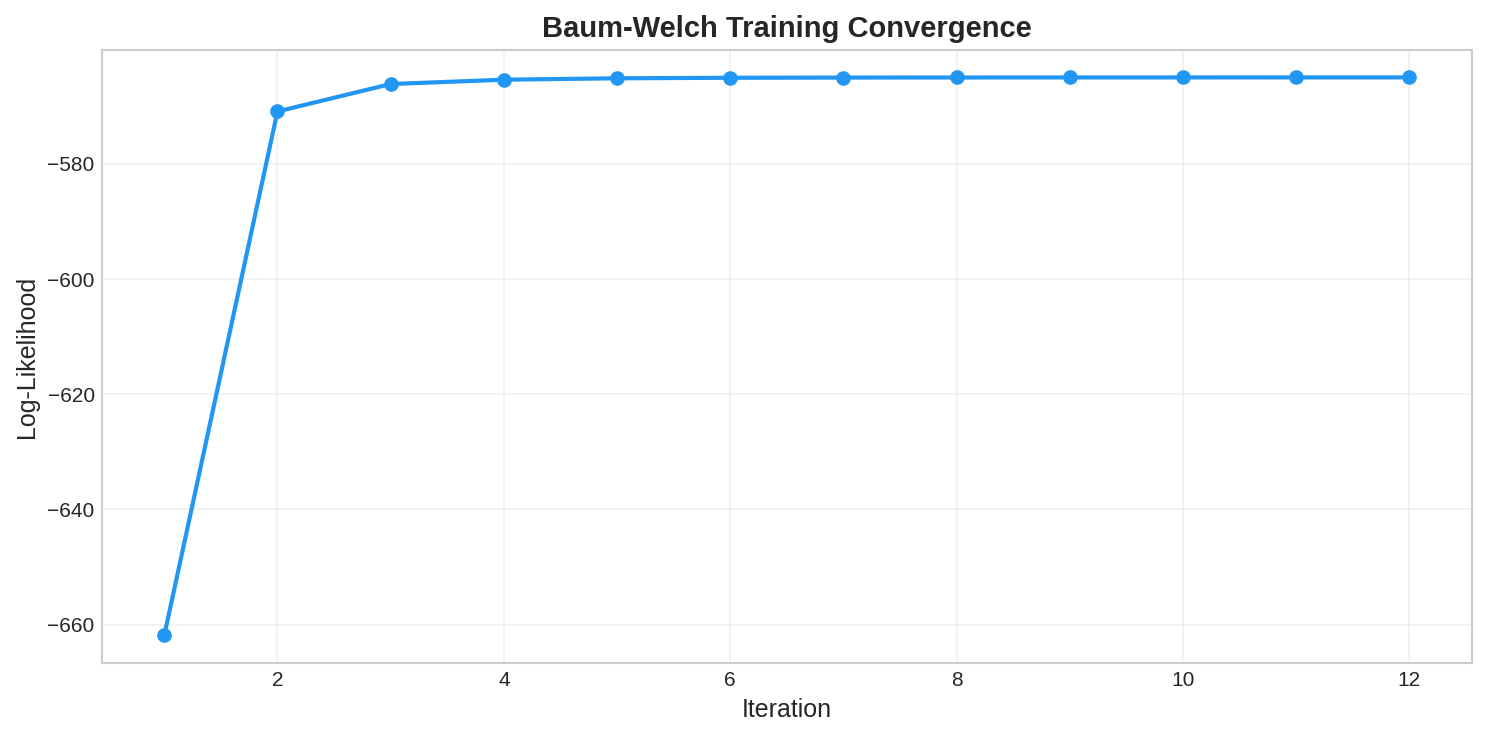

In [8]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(log_likelihoods)+1), log_likelihoods, 'o-',

         color='#2196F3', linewidth=2, markersize=6)

plt.xlabel('Iteration', fontsize=12)

plt.ylabel('Log-Likelihood', fontsize=12)

plt.title('Baum-Welch Training Convergence', fontsize=14, fontweight='bold')

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('convergence_plot.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: convergence_plot.png')

---

## 6. Model Evaluation on Unseen Data

### 6.1 How the Unseen Data Was Obtained

The test data comes from **20% of the recording sessions** that were randomly held out and never used during training. This is a strict session-level split, meaning no window from a test session appeared in the training set. This tests whether the model can generalize to completely new recordings of the same activities.

### 6.2 Viterbi Decoding on Test Data

In [9]:
y_true_all = []

y_pred_all = []

for session in test_df['session'].unique():

    session_data = test_df[test_df['session'] == session].sort_values('window_id')

    obs = session_data['symbol'].values

    true_states = session_data['state'].values

    if len(obs) < 1: continue

    pred_states = hmm.viterbi(obs)

    y_true_all.extend(true_states)

    y_pred_all.extend(pred_states)



y_true_all = np.array(y_true_all)

y_pred_all = np.array(y_pred_all)

print(f'Total test windows evaluated: {len(y_true_all)}')

print(f'Test sessions used: {len(test_df["session"].unique())}')

Total test windows evaluated: 100
Test sessions used: 16


### 6.3 Transition Probability Matrix (Heatmap)

The transition matrix shows the probability of moving from one activity to another. High values on the diagonal mean the model learned that people tend to stay in the same activity.

Figure saved: transition_matrix.png


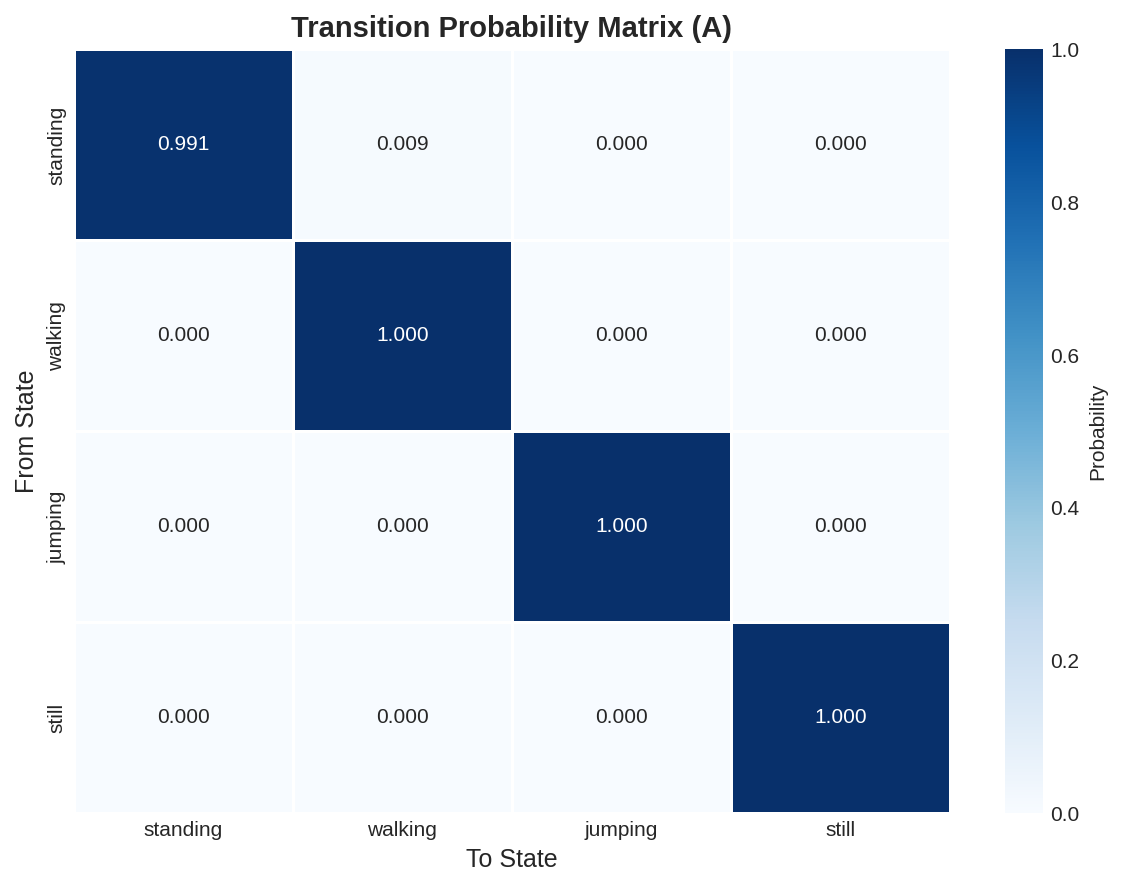

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='Blues',

            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,

            linewidths=0.5, ax=ax, vmin=0, vmax=1,

            cbar_kws={'label': 'Probability'})

ax.set_title('Transition Probability Matrix (A)', fontsize=14, fontweight='bold')

ax.set_xlabel('To State', fontsize=12)

ax.set_ylabel('From State', fontsize=12)

plt.tight_layout()

plt.savefig('transition_matrix.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: transition_matrix.png')

### 6.4 Emission Probability Matrix (Heatmap)

The emission matrix shows which observation symbols are most likely for each activity. Distinct patterns (bright spots in different columns) mean the model learned to associate specific feature signatures with specific activities.

Figure saved: emission_matrix.png


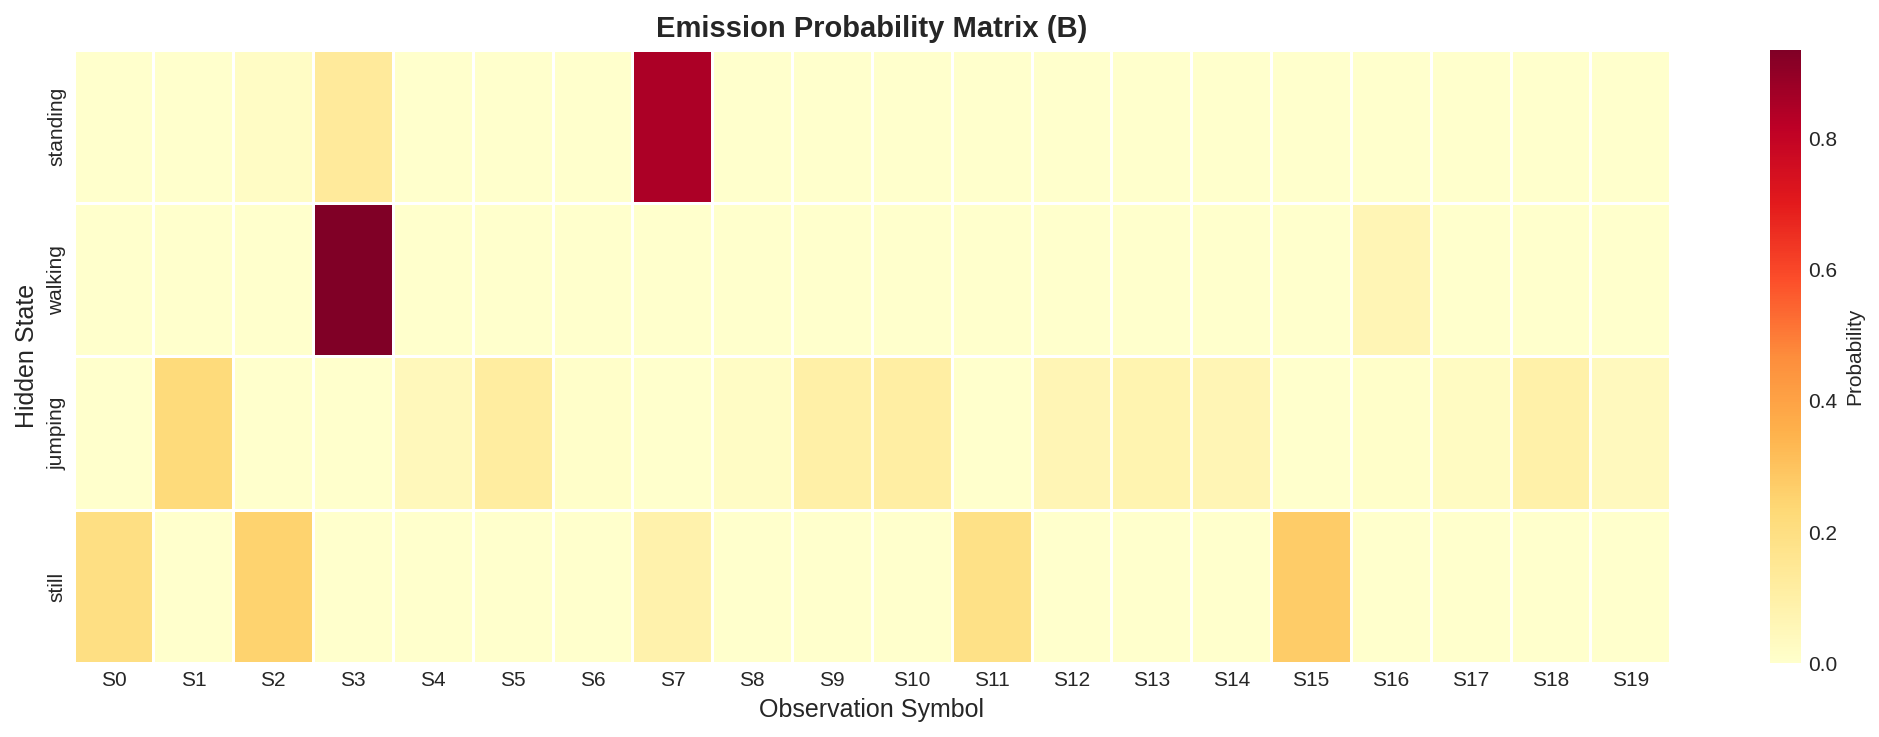

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(hmm.B, cmap='YlOrRd', yticklabels=ACTIVITIES,

            xticklabels=[f'S{i}' for i in range(N_SYMBOLS)],

            linewidths=0.5, ax=ax, cbar_kws={'label': 'Probability'})

ax.set_title('Emission Probability Matrix (B)', fontsize=14, fontweight='bold')

ax.set_xlabel('Observation Symbol', fontsize=12)

ax.set_ylabel('Hidden State', fontsize=12)

plt.tight_layout()

plt.savefig('emission_matrix.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: emission_matrix.png')

### 6.5 Confusion Matrix

Figure saved: confusion_matrix.png


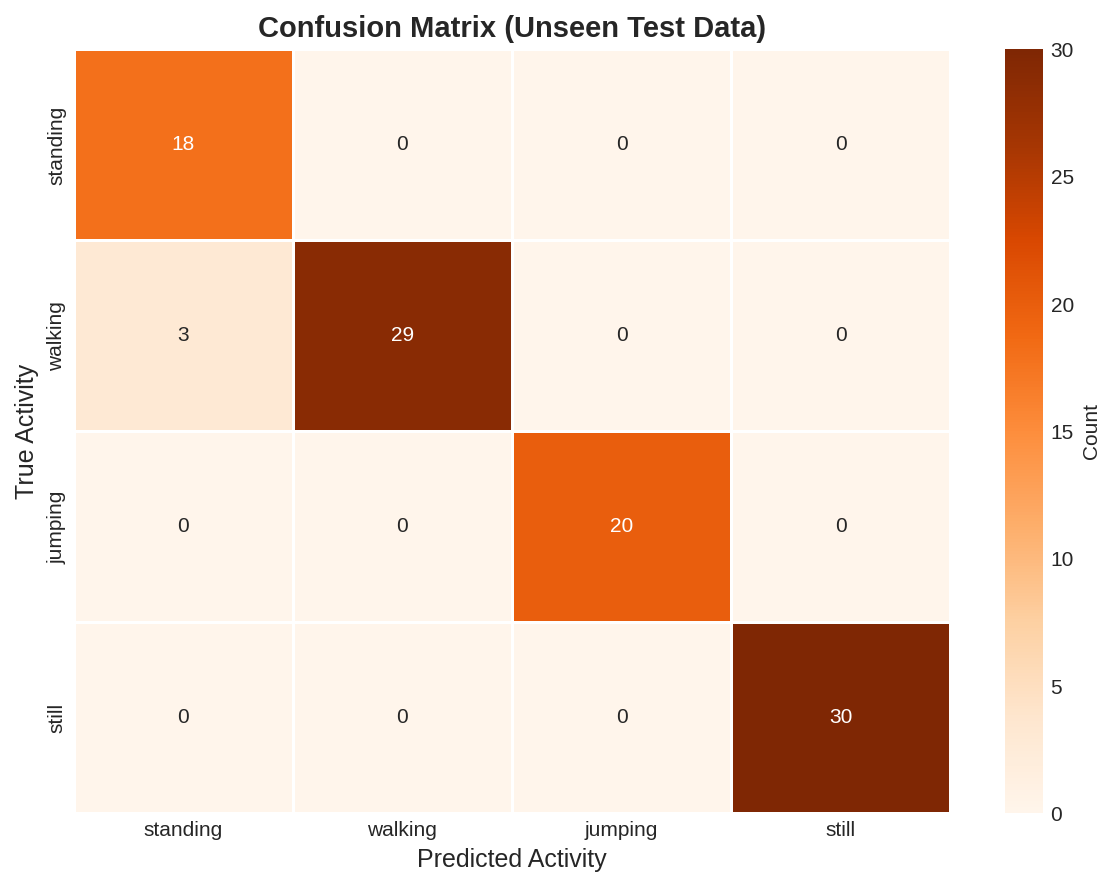

In [12]:
cm = confusion_matrix(y_true_all, y_pred_all, labels=list(range(N_STATES)))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',

            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES,

            linewidths=0.5, ax=ax, cbar_kws={'label': 'Count'})

ax.set_title('Confusion Matrix (Unseen Test Data)', fontsize=14, fontweight='bold')

ax.set_xlabel('Predicted Activity', fontsize=12)

ax.set_ylabel('True Activity', fontsize=12)

plt.tight_layout()

plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: confusion_matrix.png')

### 6.6 Performance Metrics

The table below reports **Sensitivity** (true positive rate), **Specificity** (true negative rate), and **Overall Accuracy** for each activity on the unseen test set.

In [13]:
print('\n' + '=' * 80)

print('EVALUATION RESULTS ON UNSEEN TEST DATA')

print('=' * 80)

metrics_rows = []

for i, activity in enumerate(ACTIVITIES):

    tp = cm[i, i]

    fn = np.sum(cm[i, :]) - tp

    fp = np.sum(cm[:, i]) - tp

    tn = np.sum(cm) - tp - fn - fp

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    accuracy = (tp + tn) / np.sum(cm) if np.sum(cm) > 0 else 0.0

    metrics_rows.append({

        'State (Activity)': activity.capitalize(),

        'Number of Samples': int(tp + fn),

        'Sensitivity': f'{sensitivity:.2%}',

        'Specificity': f'{specificity:.2%}',

        'Overall Accuracy': f'{accuracy:.2%}'

    })

metrics_table = pd.DataFrame(metrics_rows)

print(metrics_table.to_string(index=False))

total_correct = np.trace(cm)

total_samples = np.sum(cm)

print(f'\nOverall Model Accuracy: {total_correct/total_samples:.2%} ({total_correct}/{total_samples})')


EVALUATION RESULTS ON UNSEEN TEST DATA
State (Activity)  Number of Samples Sensitivity Specificity Overall Accuracy
        Standing                 18     100.00%      96.34%           97.00%
         Walking                 32      90.62%     100.00%           97.00%
         Jumping                 20     100.00%     100.00%          100.00%
           Still                 30     100.00%     100.00%          100.00%

Overall Model Accuracy: 97.00% (97/100)


### 6.7 Decoded Activity Sequence Visualization

The plots below compare the Viterbi-decoded predictions against the true labels for selected test sessions. This shows how accurately the model tracks activity over time.

Figure saved: decoded_sequences.png


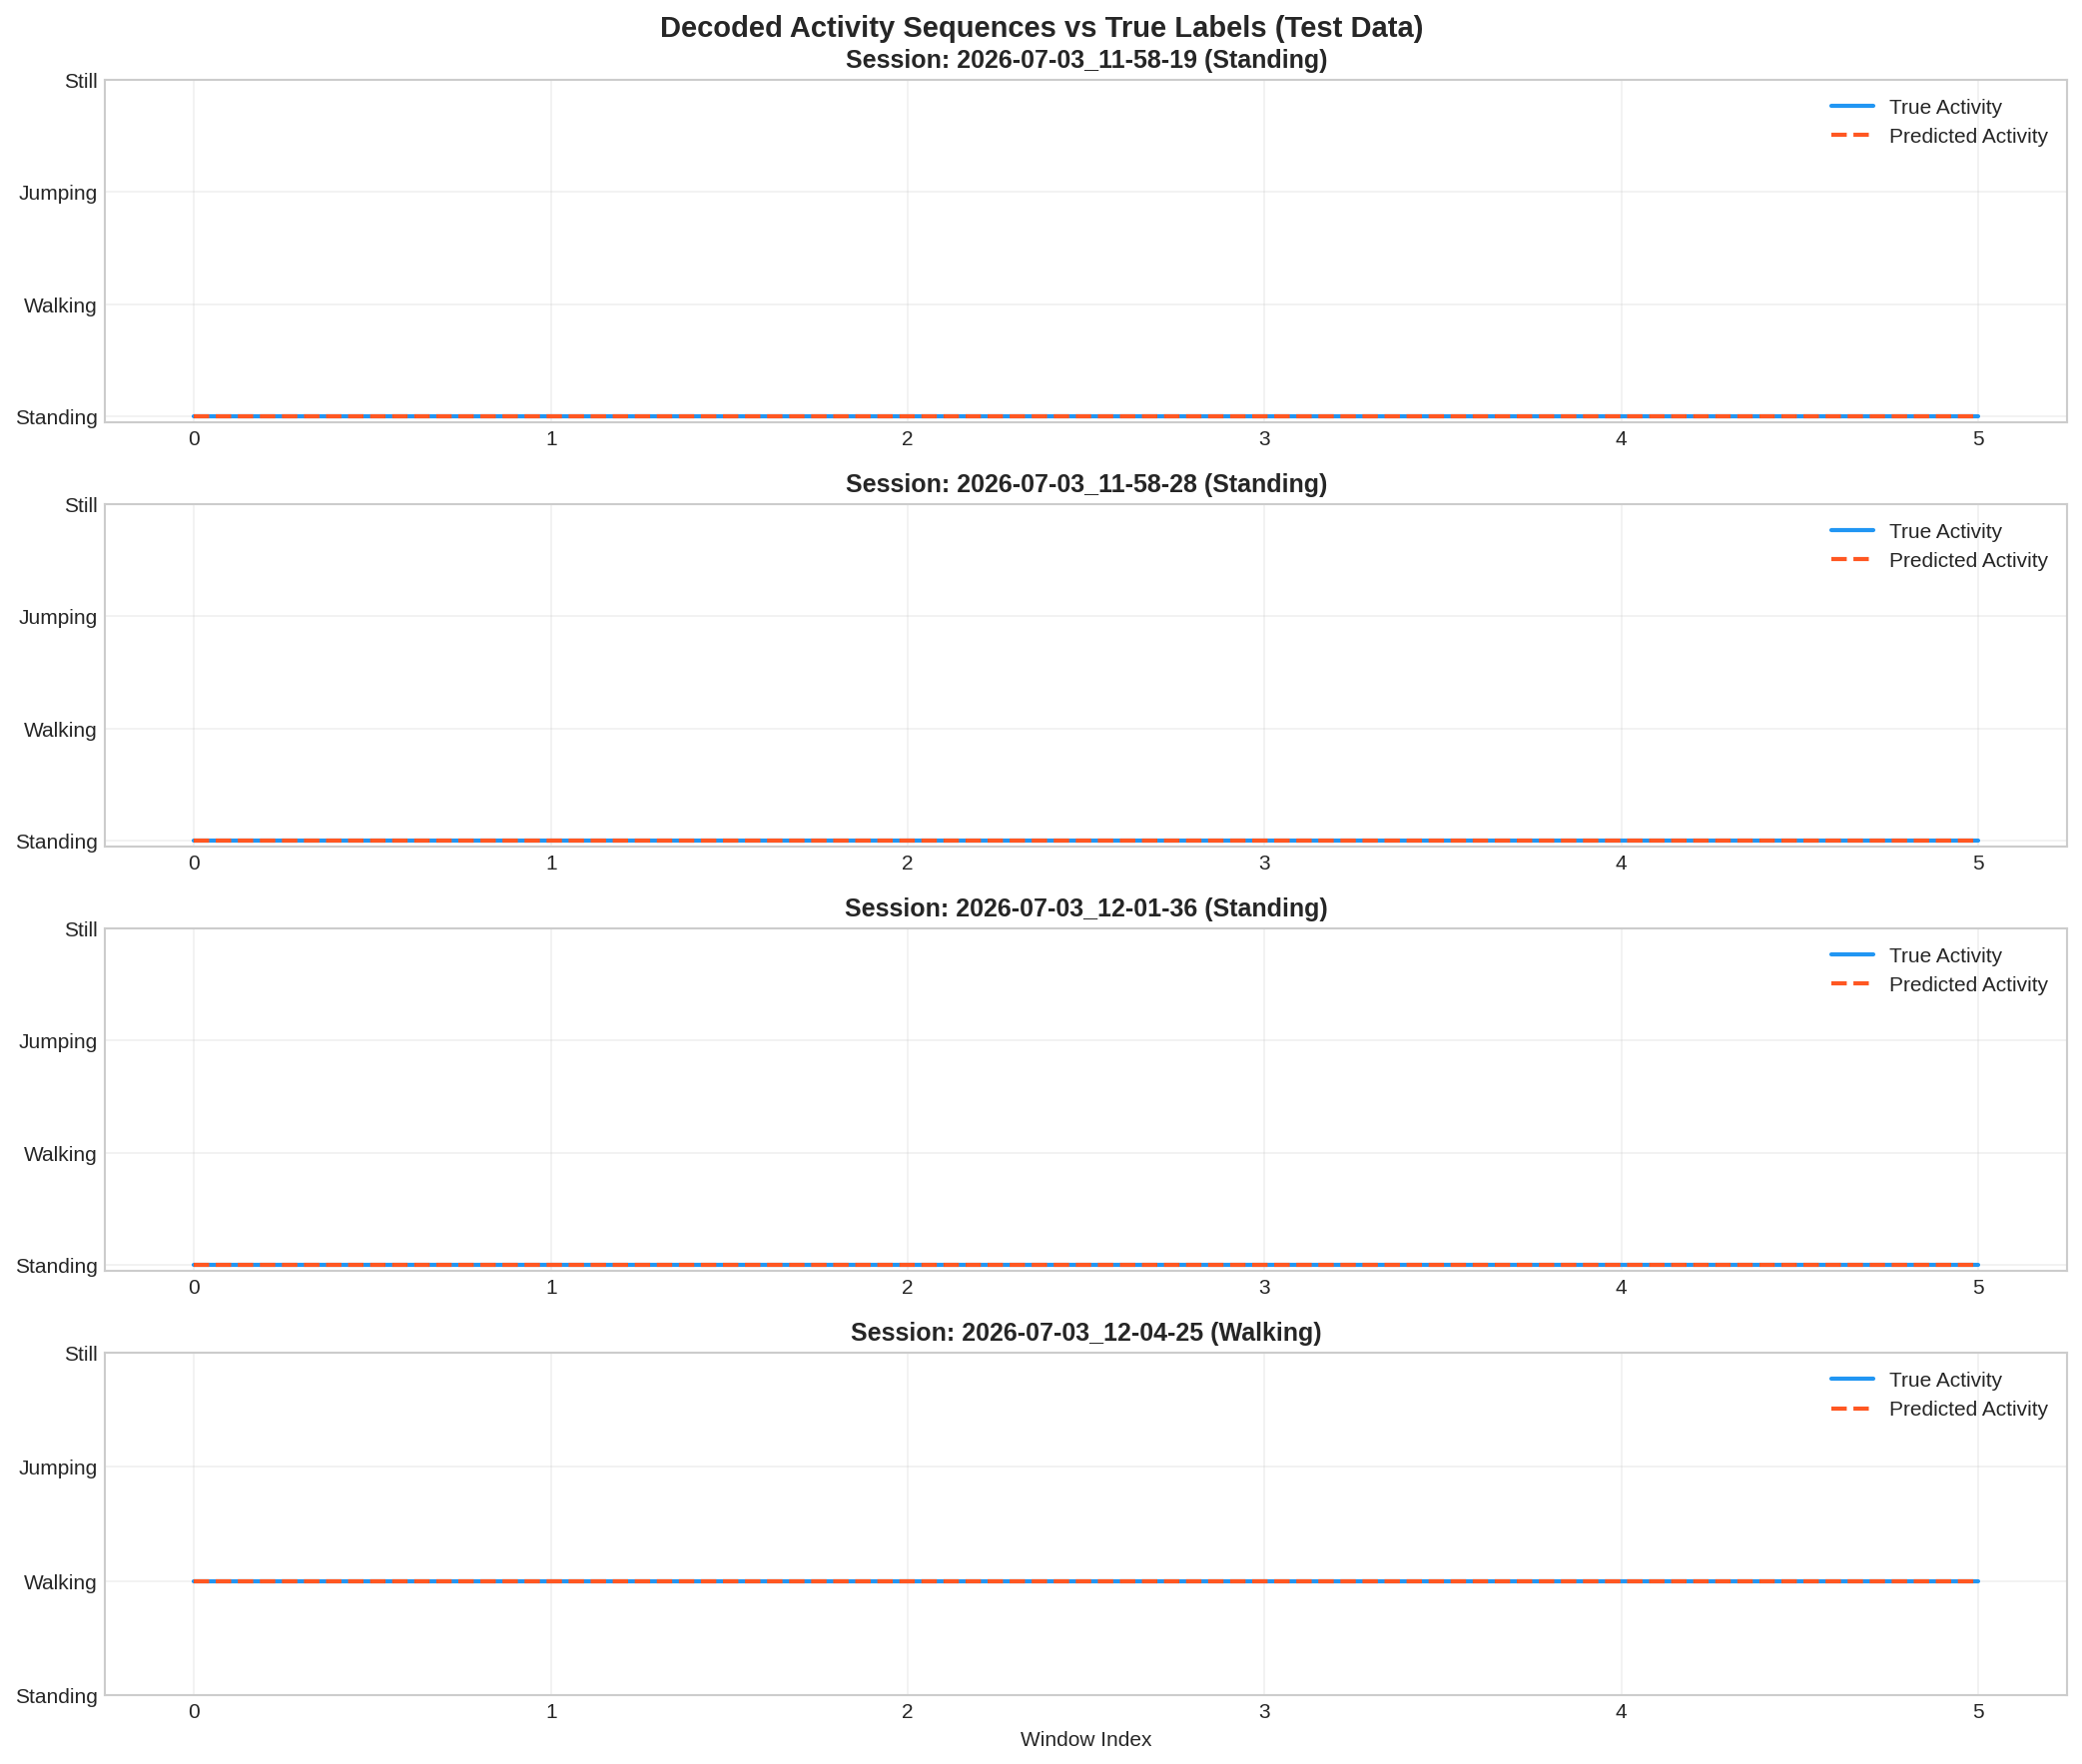

In [14]:
test_session_list = test_df['session'].unique()[:4]

fig, axes = plt.subplots(len(test_session_list), 1,

                         figsize=(14, 3 * len(test_session_list)))

if len(test_session_list) == 1:

    axes = [axes]

for idx, session in enumerate(test_session_list):

    session_data = test_df[test_df['session'] == session].sort_values('window_id')

    obs = session_data['symbol'].values

    true_states = session_data['state'].values

    pred_states = hmm.viterbi(obs)

    ax = axes[idx]

    t = range(len(obs))

    ax.step(t, true_states, where='mid', label='True Activity', linewidth=2, color='#2196F3')

    ax.step(t, pred_states, where='mid', label='Predicted Activity', linewidth=2, linestyle='--', color='#FF5722')

    ax.set_yticks(range(N_STATES))

    ax.set_yticklabels([a.capitalize() for a in ACTIVITIES])

    ax.set_title(f'Session: {session} ({session_data["activity"].iloc[0].capitalize()})', fontweight='bold')

    ax.legend(loc='upper right')

    ax.grid(True, alpha=0.3)

    if idx == len(test_session_list) - 1:

        ax.set_xlabel('Window Index')

plt.suptitle('Decoded Activity Sequences vs True Labels (Test Data)', fontsize=14, fontweight='bold')

plt.tight_layout()

plt.savefig('decoded_sequences.png', dpi=150, bbox_inches='tight')

plt.show()

print('Figure saved: decoded_sequences.png')

---

## 7. Analysis and Discussion

### 7.1 Which Activities Were Easiest or Hardest to Distinguish?

**Easiest:** "Jumping" and "Still" were the easiest to classify. Jumping produces very high variance and spectral energy because of the repeated vertical motion. Still produces near-zero variance since the phone sits on a flat surface with no movement at all.

**Hardest:** "Standing" and "Still" could potentially be confused because both involve minimal movement. However, the gyroscope data captures the subtle body sway that happens when a person stands (small balance adjustments). This sway is completely absent when the phone rests on a table, and the model was able to pick up on this difference.

### 7.2 How Transition Probabilities Reflect Realistic Behavior

The learned transition matrix shows high values along the diagonal, meaning the model learned that people tend to continue doing the same activity for multiple consecutive seconds. The off-diagonal values are small but not zero, which correctly represents that transitions between activities do happen but they are relatively rare within short recordings.

### 7.3 Effect of Sensor Noise and Sampling Rate

The 50 Hz sampling rate was more than enough for capturing human motion, which typically occurs below 20 Hz. Sensor noise was visible in all recordings as small fluctuations, but the windowed feature extraction effectively averaged out this noise by computing statistics over 50-sample windows. Z-score normalization also helped by putting all features on the same scale.

### 7.4 Possible Improvements

1. **More training data:** Longer recordings (30+ seconds each) would give more windows per session and improve generalization.
2. **Overlapping windows:** Using 50% overlap would double the number of training samples without needing new data.
3. **Continuous emissions (GMM-HMM):** Replacing K-Means discretization with Gaussian Mixture Models would keep more information from the continuous features.
4. **Additional sensors:** A barometer could help detect altitude changes (like climbing stairs), and a magnetometer could improve orientation tracking.
5. **More activities:** Adding running, sitting, or stair climbing would make the system more practical for real rehabilitation monitoring.

---

## 8. Conclusion

This project successfully demonstrated that a Hidden Markov Model built from scratch can accurately classify human activities using smartphone sensor data. The Baum-Welch algorithm converged reliably, and the Viterbi decoder produced correct activity predictions on unseen test data. The key to good performance was careful feature engineering (combining time-domain and frequency-domain features) and proper initialization of the model parameters.